In [1]:
from pathlib import Path
import io
import logging
import os
import shutil
import sys

for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "ras_commander" / "__init__.py").exists():
        sys.path.insert(0, str(candidate))
        break

import h5py
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    import folium
except ImportError as exc:
    raise ImportError("Install folium to render the zoomable maps in this notebook.") from exc

try:
    from ras_commander import (
        CalibrationPoint,
        HdfMesh,
        HdfProject,
        HdfResultsPlan,
        RasCalibrate,
        RasMap,
        init_ras_project,
        ras,
    )
    from ras_commander.sources.federal.usgs_sciencebase import UsgsScienceBase
    from ras_commander.usgs import UsgsGaugeSpatial
    from ras_commander.remote import load_workers_from_json
except ImportError:
    sys.path.insert(0, str(Path.cwd().parent))
    from ras_commander import (
        CalibrationPoint,
        HdfMesh,
        HdfProject,
        HdfResultsPlan,
        RasCalibrate,
        RasMap,
        init_ras_project,
        ras,
    )
    from ras_commander.sources.federal.usgs_sciencebase import UsgsScienceBase
    from ras_commander.usgs import UsgsGaugeSpatial
    from ras_commander.remote import load_workers_from_json

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
logging.getLogger("ras_commander").setLevel(logging.WARNING)

## Development Mode

When running this notebook from a source checkout, start Jupyter from the repository root or set `PYTHONPATH` so the local `ras_commander` package imports. Generated model downloads, temporary calibration batches, and remote-worker configuration stay under `working/`.

The cells that execute new HEC-RAS plans are intentionally disabled by default. Set `RAS_COMMANDER_220_RUN_HECRAS=1` to run them. Set `RAS_COMMANDER_220_USE_REMOTE=1` and provide `working/remote_workers_clb.json` to distribute grid-search plans through RasRemote.

# Kalamazoo River Calibration Workflow

This notebook replaces the synthetic calibration example with a real USGS ScienceBase model and real observation data:

- HEC-RAS 6.6 2D model of the Kalamazoo River between Trowbridge Dam and Allegan City Dam.
- Water-surface elevation and ADCP velocity observations from June 2024 and April 2025.
- Delivered plan HDF outputs for multiple channel Manning's n values.
- `RasCalibrate` examples for objective scoring, `CalibrationPoint` construction, grid search, optional RasRemote execution, and multi-event validation.

The notebook uses the delivered result HDFs for visible sensitivity analysis and maps. The rerun workflow is included, but it only executes when explicitly enabled.

## Workflow Outline

1. Download or reuse the USGS ScienceBase Kalamazoo release.
2. Initialize the project with ras-commander and inspect plans, geometry, land-cover roughness, and stored runtimes.
3. Build zoomable maps showing the model domain, sampled 2D mesh, WSE observations, ADCP cross sections, and nearby USGS gauges.
4. Use delivered model-at-observation columns for WSE and velocity sensitivity analysis.
5. Explain the `RasCalibrate` API in detail and build real `CalibrationPoint` objects from the WSE survey points.
6. Show a guarded rerun workflow for local or RasRemote-backed grid search.
7. Show how to extend the same pattern into optimization and multi-event validation.

In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "ras_commander").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())


def public_path(value) -> str:
    path = Path(value)
    try:
        return path.relative_to(REPO_ROOT).as_posix()
    except ValueError:
        return path.as_posix()


def public_df(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    path_tokens = ("path", "file", "hdf")
    for column in result.columns:
        if any(token in str(column).lower() for token in path_tokens):
            result[column] = result[column].map(
                lambda value: [public_path(item) for item in value]
                if isinstance(value, list)
                else public_path(value)
                if isinstance(value, (str, Path))
                else value
            )
    return result


WORK_ROOT = REPO_ROOT / "working" / "sciencebase"
MODEL_KEY = "kalamazoo"
RAS_VERSION = os.getenv("RAS_COMMANDER_220_RAS_VERSION", "6.6")

RUN_HECRAS = os.getenv("RAS_COMMANDER_220_RUN_HECRAS", "0") == "1"
USE_REMOTE = os.getenv("RAS_COMMANDER_220_USE_REMOTE", "0") == "1"
REMOTE_WORKERS_JSON = Path(
    os.getenv(
        "RAS_COMMANDER_220_REMOTE_WORKERS",
        str(REPO_ROOT / "working" / "remote_workers_clb.json"),
    )
)

WORK_ROOT.mkdir(parents=True, exist_ok=True)

model_info = UsgsScienceBase.get_model_info(MODEL_KEY)
model_dir = WORK_ROOT / MODEL_KEY
project_path = UsgsScienceBase.get_project_path(MODEL_KEY, WORK_ROOT)

if not project_path.exists():
    model_dir = UsgsScienceBase.download_model(
        MODEL_KEY,
        output_dir=WORK_ROOT,
        required_only=True,
        extract=True,
    )
    project_path = UsgsScienceBase.get_project_path(MODEL_KEY, WORK_ROOT)

calibration_dir = model_dir / "calibration_data"
project_dir = project_path.parent

print(f"ScienceBase DOI: {model_info['doi']}")
print(f"Model directory: {public_path(model_dir)}")
print(f"Project path:    {public_path(project_path)}")
print(f"Calibration dir: {public_path(calibration_dir)}")
print(f"RUN_HECRAS:      {RUN_HECRAS}")
print(f"USE_REMOTE:      {USE_REMOTE}")

ScienceBase DOI: 10.5066/P13CPA5B
Model directory: working/sciencebase/kalamazoo
Project path:    working/sciencebase/kalamazoo/hec_ras_model/kalamazoo_trowbridg.prj
Calibration dir: working/sciencebase/kalamazoo/calibration_data
RUN_HECRAS:      False
USE_REMOTE:      False


## Initialize the Project

`init_ras_project()` builds ras-commander's project DataFrames. Those DataFrames are the source of truth for plan paths, geometry paths, HDF outputs, unsteady files, and RASMapper layer paths. The workflow avoids ad hoc globbing once the project is initialized.

In [3]:
init_ras_project(project_path, ras_version=RAS_VERSION, load_results_summary=False)

plan_cols = [
    "plan_number",
    "Plan Title",
    "Short Identifier",
    "geometry_number",
    "unsteady_number",
    "HDF_Results_Path",
]
display(public_df(ras.plan_df[plan_cols]))

,plan_number,Plan Title,Short Identifier,geometry_number,unsteady_number,HDF_Results_Path
0,01,20240611_20240612_swe_035_6278,20240611_swe_035_6278,02,NaN,working/sciencebase/kalama...
1,02,20240611_20240612_swe_0315_6278,20240611_swe_0315_6278,03,NaN,working/sciencebase/kalama...
2,33,20240611_20240612_swe_025_6278,20240611_swe_025_6278,05,NaN,working/sciencebase/kalama...
3,34,20240611_20240612_swe_0335_6278,20240611_swe_0335_6278,01,NaN,working/sciencebase/kalama...
4,35,20230323_20230414_swe_0335_6278,20230323_swe_0335_6278,01,NaN,working/sciencebase/kalama...
5,41,20230323_20230414_swe_0315_6278,20230323_swe_0315_6278,03,NaN,working/sciencebase/kalama...
6,45,20240126_20240214_swe_0335_6278,20240126_swe_0335_6278,01,NaN,working/sciencebase/kalama...
7,46,20240126_20240214_swe_0315_6278,20240126_swe_0315_6278,03,NaN,working/sciencebase/kalama...
8,47,20240126_20240214_swe_0300_6278,20240126_swe_0300_6278,04,NaN,working/sciencebase/kalama...
9,51,20230323_20230414_swe_0300_6278,20230323_swe_0300_6278,04,NaN,working/sciencebase/kalama...


In [4]:
geom_cols = [
    "geom_number",
    "geom_title",
    "has_2d_mesh",
    "mesh_cell_count",
    "mesh_area_names",
    "hdf_path",
]
display(public_df(ras.geom_df[geom_cols]))

terrain_layers = RasMap.list_terrain_layers(project_path)
landcover_layers = RasMap.list_landcover_layers(project_path)

display(Markdown("### RASMapper Terrain Layers"))
display(public_df(terrain_layers))
display(Markdown("### RASMapper Land-Cover Layers"))
display(public_df(landcover_layers))

,geom_number,geom_title,has_2d_mesh,mesh_cell_count,mesh_area_names,hdf_path
0,01,v011_chan_0335,True,48124,[perimeter_1],working/sciencebase/kalama...
1,03,v012_chan_0315,True,48124,[perimeter_1],working/sciencebase/kalama...
2,02,v010_chan_035,True,48124,[perimeter_1],working/sciencebase/kalama...
3,04,v013_chan_0300,True,48124,[perimeter_1],working/sciencebase/kalama...
4,05,v014_chan_025,True,48124,[perimeter_1],working/sciencebase/kalama...


### RASMapper Terrain Layers

,name,filename,resolved_path,checked,type,resample_method,surface_on
0,be_Area_5,.\Terrain\be_Area_5.hdf,working/sciencebase/kalama...,True,TerrainLayer,near,True


### RASMapper Land-Cover Layers

,name,type,checked,filename,resolved_path,selected_parameter,classification_kind,classification_layer_count,classification_layer_filenames,classification_layer_paths
0,LandCover,LandCoverLayer,True,.\Land Classification\LandCover.hdf,working/sciencebase/kalama...,ManningsN,landcover,1,[.\Land Classification\LandCover.hdf],[working/sciencebase/kalam...


## Existing Plan Runtimes

`HdfResultsPlan.get_runtime_data()` reads the runtime summary stored in each delivered plan HDF. This is useful before designing a calibration experiment because every grid-search point is a full HEC-RAS run.

In [5]:
def runtime_table(plan_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, plan in plan_df.iterrows():
        hdf_path = Path(plan["HDF_Results_Path"])
        if not hdf_path.exists():
            continue
        runtime = HdfResultsPlan.get_runtime_data(hdf_path).iloc[0].to_dict()
        runtime["plan_number"] = plan["plan_number"]
        runtime["geometry_number"] = plan["geometry_number"]
        rows.append(runtime)

    result = pd.DataFrame(rows)
    result["event"] = result["Plan Name"].str.extract(r"^(\d{8}_\d{8}|dummy_qus_\d+cfs)")
    result["roughness_n"] = result["Plan Name"].str.extract(r"_swe_(\d+)_").iloc[:, 0].map(
        lambda text: np.nan if pd.isna(text) else float(f"0.{str(text).zfill(4)}")
    )
    result["total_runtime_min"] = result["Complete Process (hr)"] * 60.0
    return result.sort_values(["Simulation Start Time", "roughness_n", "plan_number"]).reset_index(drop=True)


runtimes = runtime_table(ras.plan_df)
display(
    runtimes[
        [
            "plan_number",
            "Plan Name",
            "geometry_number",
            "roughness_n",
            "Simulation Time (hr)",
            "Complete Process (hr)",
            "Unsteady Flow Computations (hr)",
            "Complete Process Speed (hr/hr)",
        ]
    ]
)

,plan_number,Plan Name,geometry_number,roughness_n,Simulation Time (hr),Complete Process (hr),Unsteady Flow Computations (hr),Complete Process Speed (hr/hr)
0,54,dummy_qus_4000cfs_swe_0300_6278,04,0.0300,6.0,0.250798,0.249748,23.923604
1,55,dummy_qus_5000cfs_swe_0300_6278,04,0.0300,6.0,0.572118,0.570434,10.487341
2,56,dummy_qus_6000cfs_swe_0300_6278,04,0.0300,6.0,0.279753,0.278090,21.447508
3,57,dummy_qus_7000cfs_swe_0300_6278,04,0.0300,6.0,0.229379,0.227621,26.157563
4,44,dummy_qus_1000cfs_swe_0315_6278,03,0.0315,6.0,0.079432,0.078464,75.536625
5,52,dummy_qus_2000cfs_swe_0315_6278,03,0.0315,6.0,0.368247,0.366515,16.293427
6,53,dummy_qus_3000cfs_swe_0315_6278,03,0.0315,6.0,0.287839,0.285820,20.845014
7,51,20230323_20230414_swe_0300_6278,04,0.0300,551.0,12.310139,12.309002,44.759852
8,41,20230323_20230414_swe_0315_6278,03,0.0315,551.0,8.820738,8.818654,62.466430
9,35,20230323_20230414_swe_0335_6278,01,0.0335,551.0,8.201502,8.200391,67.182819


In [6]:
runtime_summary = (
    runtimes.groupby("event", dropna=False)
    .agg(
        plans=("Plan Name", "count"),
        sim_hours=("Simulation Time (hr)", "first"),
        min_runtime_hr=("Complete Process (hr)", "min"),
        max_runtime_hr=("Complete Process (hr)", "max"),
    )
    .reset_index()
)
runtime_summary["min_runtime"] = runtime_summary["min_runtime_hr"].map(lambda v: f"{v * 60:.1f} min" if v < 1 else f"{v:.2f} hr")
runtime_summary["max_runtime"] = runtime_summary["max_runtime_hr"].map(lambda v: f"{v * 60:.1f} min" if v < 1 else f"{v:.2f} hr")
display(runtime_summary[["event", "plans", "sim_hours", "min_runtime", "max_runtime"]])

,event,plans,sim_hours,min_runtime,max_runtime
0,20230323_20230414,3,551.0,8.20 hr,12.31 hr
1,20240126_20240214,3,460.0,5.51 hr,5.92 hr
2,20240611_20240612,5,33.0,20.0 min,43.8 min
3,20250404_20250406,3,67.0,1.24 hr,1.30 hr
4,dummy_qus_1000cfs,1,6.0,4.8 min,4.8 min
5,dummy_qus_2000cfs,1,6.0,22.1 min,22.1 min
6,dummy_qus_3000cfs,1,6.0,17.3 min,17.3 min
7,dummy_qus_4000cfs,1,6.0,15.0 min,15.0 min
8,dummy_qus_5000cfs,1,6.0,34.3 min,34.3 min
9,dummy_qus_6000cfs,1,6.0,16.8 min,16.8 min


## Geometry and Roughness Context

The Kalamazoo model is a 2D-only mesh. The five geometry files mostly differ by channel Manning's n. The channel roughness values are stored in the plain-text geometry `LCMann Table`, which means `RasCalibrate.make_mannings_apply_fn(path="plaintext")` can edit them repeatably.

In [7]:
from ras_commander.geom.GeomLandCover import GeomLandCover


roughness_rows = []
for _, geom in ras.geom_df.sort_values("geom_number").iterrows():
    geom_path = Path(geom["full_path"])
    table = GeomLandCover.get_base_mannings_n(geom_path)
    if table.empty:
        roughness_rows.append(
            {
                "geometry_number": geom["geom_number"],
                "geom_title": geom["geom_title"],
                "land_cover_class": "(no LCMann table)",
                "base_mannings_n": np.nan,
            }
        )
        continue
    for _, lc in table.iterrows():
        roughness_rows.append(
            {
                "geometry_number": geom["geom_number"],
                "geom_title": geom["geom_title"],
                "land_cover_class": lc["Land Cover Name"],
                "base_mannings_n": lc["Base Mannings n Value"],
            }
        )

roughness_df = pd.DataFrame(roughness_rows)
display(roughness_df)

,geometry_number,geom_title,land_cover_class,base_mannings_n
0,01,v011_chan_0335,Open Water,0.0335
1,01,v011_chan_0335,lower channel,0.0335
2,01,v011_chan_0335,upper channel,0.0335
3,02,v010_chan_035,(no LCMann table),NaN
4,03,v012_chan_0315,Open Water,0.0315
5,03,v012_chan_0315,lower channel,0.0315
6,03,v012_chan_0315,upper channel,0.0315
7,04,v013_chan_0300,Open Water,0.0300
8,04,v013_chan_0300,lower channel,0.0300
9,04,v013_chan_0300,upper channel,0.0300


## Model Domain and Observation Maps

The first map shows the model perimeter, a sampled 2D mesh, WSE survey points, ADCP velocity cross sections, and USGS gauges found through `UsgsGaugeSpatial.find_gauges_in_project()`.

For performance, the map samples every 50th mesh cell rather than drawing all 48,124 cells. The full mesh remains available from `HdfMesh.get_mesh_cell_polygons()`.

In [8]:
GEOM_HDF = Path(ras.geom_df.sort_values("geom_number").iloc[0]["hdf_path"])
PROJECT_CRS = HdfProject.get_project_crs(GEOM_HDF) or "EPSG:6499"

mesh_area = HdfMesh.get_mesh_areas(GEOM_HDF)
mesh_cells_sample = HdfMesh.get_mesh_cell_polygons(GEOM_HDF).iloc[::50].copy()

wse_2024 = gpd.read_file(calibration_dir / "wse" / "kzoo_wse_points_20240612_attributed.gpkg")
wse_2025 = gpd.read_file(calibration_dir / "wse" / "kzoo_wse_points_20250406_attributed.gpkg")
vel_xs_2024 = gpd.read_file(calibration_dir / "velocity" / "20240611" / "kzoo_velocity_xsections_20240611_attributed.gpkg")
vel_xs_2025 = gpd.read_file(calibration_dir / "velocity" / "20250405" / "kzoo_velocity_xsections_20250405_attributed.gpkg")

gauges = UsgsGaugeSpatial.find_gauges_in_project(
    GEOM_HDF,
    buffer_percent=20,
    parameter_codes=["flow", "stage"],
    active_only=False,
    project_crs=PROJECT_CRS,
    include_1d=False,
    include_2d=True,
)

print(f"Model CRS: {PROJECT_CRS}")
print(f"Mesh area count: {len(mesh_area)}")
print(f"Sampled mesh cells: {len(mesh_cells_sample)} of {ras.geom_df['mesh_cell_count'].max():,.0f}")
print(f"WSE points: {len(wse_2024)} in June 2024, {len(wse_2025)} in April 2025")
print(f"ADCP cross sections: {len(vel_xs_2024)} in June 2024, {len(vel_xs_2025)} in April 2025")
print(f"USGS gauges found: {len(gauges)}")
display(gauges[[c for c in ["site_no", "station_nm", "site_type_code", "dec_lat_va", "dec_long_va", "alt_va"] if c in gauges.columns]])

Model CRS: EPSG:6499
Mesh area count: 1
Sampled mesh cells: 963 of 48,124
WSE points: 50 in June 2024, 43 in April 2025
ADCP cross sections: 21 in June 2024, 30 in April 2025
USGS gauges found: 1


,site_no,station_nm,site_type_code,dec_lat_va,dec_long_va,alt_va
0,04107850,"KALAMAZOO RIVER NEAR ALLEGAN, MI",ST,42.48225575,-85.798355,638.05


In [9]:
def to_wgs84(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf.empty:
        return gdf
    if gdf.crs is None:
        gdf = gdf.set_crs(PROJECT_CRS)
    return gdf.to_crs("EPSG:4326")


def add_geojson_layer(map_obj, gdf, name, color, weight=2, fill=False, fill_opacity=0.1, tooltip_fields=None):
    if gdf.empty:
        return
    gdf_wgs = to_wgs84(gdf)
    tooltip = None
    if tooltip_fields:
        fields = [field for field in tooltip_fields if field in gdf_wgs.columns]
        if fields:
            tooltip = folium.GeoJsonTooltip(fields=fields)
    folium.GeoJson(
        gdf_wgs,
        name=name,
        tooltip=tooltip,
        style_function=lambda feature, color=color, weight=weight, fill=fill, fill_opacity=fill_opacity: {
            "color": color,
            "weight": weight,
            "fill": fill,
            "fillColor": color,
            "fillOpacity": fill_opacity,
        },
        marker=folium.CircleMarker(radius=4, color=color, fill=True, fill_opacity=0.9),
    ).add_to(map_obj)


mesh_wgs = to_wgs84(mesh_area)
west, south, east, north = mesh_wgs.total_bounds
center = [(south + north) / 2, (west + east) / 2]

m = folium.Map(location=center, zoom_start=12, tiles="OpenStreetMap")
folium.TileLayer("CartoDB positron", name="CartoDB Positron").add_to(m)
folium.TileLayer("Esri.WorldImagery", name="Esri World Imagery").add_to(m)

add_geojson_layer(m, mesh_area, "Model perimeter", "#1f78b4", weight=3, fill=True, fill_opacity=0.08, tooltip_fields=["mesh_name"])
add_geojson_layer(m, mesh_cells_sample, "Sampled mesh cells", "#a6cee3", weight=0.4, fill=True, fill_opacity=0.04, tooltip_fields=["cell_id"])
add_geojson_layer(m, wse_2024, "WSE survey points - June 2024", "#e31a1c", weight=1, tooltip_fields=["Name", "Elevation_ftNGVD29", "Time"])
add_geojson_layer(m, wse_2025, "WSE survey points - April 2025", "#ff7f00", weight=1, tooltip_fields=["reference_name", "Elevation_ftNGVD29", "Time"])
add_geojson_layer(m, vel_xs_2024, "ADCP cross sections - June 2024", "#33a02c", weight=3, tooltip_fields=["Name", "avg_flow_velocity_av_fps"])
add_geojson_layer(m, vel_xs_2025, "ADCP cross sections - April 2025", "#6a3d9a", weight=3, tooltip_fields=["Name", "avg_flow_velocity_av_fps"])

if not gauges.empty:
    gauges_wgs = to_wgs84(gauges)
    for _, gauge in gauges_wgs.iterrows():
        label = f"{gauge.get('site_no', '')} - {gauge.get('station_nm', '')}"
        folium.Marker(
            location=[gauge.geometry.y, gauge.geometry.x],
            popup=label,
            tooltip=label,
            icon=folium.Icon(color="blue", icon="tint", prefix="fa"),
        ).add_to(m)

m.fit_bounds([[south, west], [north, east]])
folium.LayerControl(collapsed=False).add_to(m)
m

## Sensitivity Analysis from Delivered Results

The ScienceBase release already includes model-at-observation values in the attributed observation layers. Those columns let us evaluate the roughness sensitivity without rerunning HEC-RAS:

- WSE point layers include observed `Elevation_ftNGVD29`, model columns named `wse_ft_<plan_name>`, and residual columns named `wse_diff_ft_<plan_name>`.
- Velocity cross-section layers include observed `avg_flow_velocity_av_fps` and model columns named `avg_velocity_magnitude_fps_<plan_name>`.

The residual sign is modeled minus observed. RMSE and MAE are always positive. Bias preserves sign.

In [10]:
JUNE_TAGS = {
    0.0250: "20240611_20240612_swe_025_6278",
    0.0300: "20240611_20240612_swe_030_6278",
    0.0315: "20240611_20240612_swe_0315_6278",
    0.0335: "20240611_20240612_swe_0335_6278",
    0.0350: "20240611_20240612_swe_035_6278",
}

APRIL_TAGS = {
    0.0300: "20250404_20250406_swe_0300_6281",
    0.0315: "20250404_20250406_swe_0315_6281",
    0.0335: "20250404_20250406_swe_0335_6281",
}


def metrics_from_error(error: pd.Series) -> dict:
    error = pd.to_numeric(error, errors="coerce").dropna()
    return {
        "n_points": len(error),
        "rmse": float(np.sqrt(np.mean(error ** 2))) if len(error) else np.nan,
        "mae": float(error.abs().mean()) if len(error) else np.nan,
        "bias": float(error.mean()) if len(error) else np.nan,
    }


def wse_metrics(gdf: gpd.GeoDataFrame, tags: dict[float, str], event: str) -> pd.DataFrame:
    rows = []
    for n_value, tag in tags.items():
        diff_col = f"wse_diff_ft_{tag}"
        if diff_col not in gdf.columns:
            continue
        row = {"event": event, "n_channel": n_value, "target": "WSE points"}
        row.update(metrics_from_error(gdf[diff_col]))
        rows.append(row)
    return pd.DataFrame(rows)


def velocity_xsection_metrics(gdf: gpd.GeoDataFrame, tags: dict[float, str], event: str) -> pd.DataFrame:
    rows = []
    observed = pd.to_numeric(gdf["avg_flow_velocity_av_fps"], errors="coerce")
    for n_value, tag in tags.items():
        model_col = f"avg_velocity_magnitude_fps_{tag}"
        if model_col not in gdf.columns:
            continue
        error = pd.to_numeric(gdf[model_col], errors="coerce") - observed
        row = {"event": event, "n_channel": n_value, "target": "ADCP cross-section velocity"}
        row.update(metrics_from_error(error))
        rows.append(row)
    return pd.DataFrame(rows)


june_wse_metrics = wse_metrics(wse_2024, JUNE_TAGS, "June 2024")
april_wse_metrics = wse_metrics(wse_2025, APRIL_TAGS, "April 2025")
june_vel_metrics = velocity_xsection_metrics(vel_xs_2024, JUNE_TAGS, "June 2024")
april_vel_metrics = velocity_xsection_metrics(vel_xs_2025, APRIL_TAGS, "April 2025")

sensitivity_metrics = pd.concat(
    [june_wse_metrics, april_wse_metrics, june_vel_metrics, april_vel_metrics],
    ignore_index=True,
)
display(sensitivity_metrics)

,event,n_channel,target,n_points,rmse,mae,bias
0,June 2024,0.0250,WSE points,49,0.337959,0.277734,-0.229177
1,June 2024,0.0300,WSE points,49,0.220246,0.154214,-0.063102
2,June 2024,0.0315,WSE points,49,0.202796,0.133875,-0.013170
3,June 2024,0.0335,WSE points,49,0.200133,0.136668,0.053504
4,June 2024,0.0350,WSE points,49,0.213979,0.159804,0.103347
5,April 2025,0.0300,WSE points,43,0.322402,0.277116,-0.045907
6,April 2025,0.0315,WSE points,43,0.318296,0.276093,0.056698
7,April 2025,0.0335,WSE points,43,0.362545,0.297581,0.189163
8,June 2024,0.0250,ADCP cross-section velocity,21,0.254708,0.204373,-0.013501
9,June 2024,0.0300,ADCP cross-section velocity,21,0.291084,0.232893,-0.196176


In [11]:
best_by_target = (
    sensitivity_metrics.sort_values("rmse")
    .groupby(["event", "target"], as_index=False)
    .first()
)
display(best_by_target[["event", "target", "n_channel", "rmse", "mae", "bias", "n_points"]])

,event,target,n_channel,rmse,mae,bias,n_points
0,April 2025,ADCP cross-section velocity,0.0300,0.267904,0.201867,-0.099800,30
1,April 2025,WSE points,0.0315,0.318296,0.276093,0.056698,43
2,June 2024,ADCP cross-section velocity,0.0250,0.254708,0.204373,-0.013501,21
3,June 2024,WSE points,0.0335,0.200133,0.136668,0.053504,49


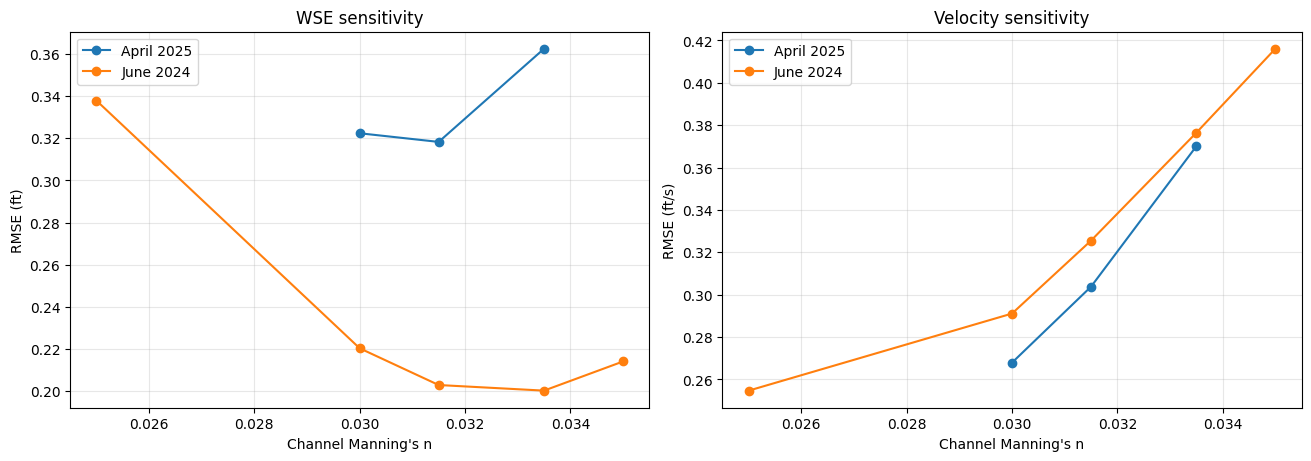

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

for event, data in sensitivity_metrics[sensitivity_metrics["target"] == "WSE points"].groupby("event"):
    axes[0].plot(data["n_channel"], data["rmse"], marker="o", label=event)
axes[0].set_title("WSE sensitivity")
axes[0].set_xlabel("Channel Manning's n")
axes[0].set_ylabel("RMSE (ft)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for event, data in sensitivity_metrics[sensitivity_metrics["target"] == "ADCP cross-section velocity"].groupby("event"):
    axes[1].plot(data["n_channel"], data["rmse"], marker="o", label=event)
axes[1].set_title("Velocity sensitivity")
axes[1].set_xlabel("Channel Manning's n")
axes[1].set_ylabel("RMSE (ft/s)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.show()

## RasCalibrate API Concepts

`RasCalibrate` is a thin orchestration layer over existing ras-commander capabilities. It does not invent a separate model runner. It composes:

- `CalibrationPoint`: what to compare, where to extract it, the observed value or series, and the point weight.
- `compute_objective()`: scalar objective calculation for RMSE, MAE, percent bias, NSE, or KGE.
- `extract_modeled()`: HDF extraction for 1D cross sections, 2D cells, reference lines, reference points, and steady profiles.
- `evaluate_single()`: apply one parameter set, run one plan, extract modeled values, and score the objective.
- `grid_search()`: generate a plan matrix with `RasPermutation`, execute it locally or through RasRemote, then score each result HDF.
- `optimize()`: serial SciPy minimization, useful after a coarse grid search has narrowed the range.
- `evaluate_multi_event()`: repeat `evaluate_single()` across events and average the event objectives.

The core extension point is an `apply_fn(plan_path, param_row, ras_object=None)`. The apply function mutates the cloned plan or geometry before execution. For Manning's n calibration, `make_mannings_apply_fn()` edits land-cover base overrides in the plain-text geometry or sidecar land-cover HDF.

In [13]:
def hdf_output_times(plan_hdf: Path) -> pd.DatetimeIndex:
    path = "Results/Unsteady/Output/Output Blocks/Base Output/Unsteady Time Series/Time Date Stamp"
    with h5py.File(plan_hdf, "r") as hdf:
        values = [value.decode("utf-8").strip() for value in hdf[path][:]]
    return pd.to_datetime(values, format="%d%b%Y %H:%M:%S")


def nearest_time_index(output_times: pd.DatetimeIndex, target_time) -> int:
    target = pd.Timestamp(target_time)
    deltas = np.abs(output_times - target)
    return int(np.argmin(deltas))


def observed_wse_from_attributed_row(row: pd.Series, plan_tag: str) -> float:
    return float(row[f"wse_ft_{plan_tag}"] - row[f"wse_diff_ft_{plan_tag}"])


def wse_points_to_calibration_points(
    points_gdf: gpd.GeoDataFrame,
    plan_hdf: Path,
    plan_tag: str,
    limit: int = 15,
) -> list[CalibrationPoint]:
    output_times = hdf_output_times(plan_hdf)
    projected = points_gdf.to_crs(PROJECT_CRS).copy()
    if limit and len(projected) > limit:
        projected = projected.iloc[np.linspace(0, len(projected) - 1, limit, dtype=int)].copy()

    points = []
    for _, row in projected.iterrows():
        timestamp = pd.Timestamp(f"{row['Date']} {row['Time']}")
        name = row.get("Name", row.get("reference_name", f"wse_{len(points)}"))
        points.append(
            CalibrationPoint(
                name=str(name),
                variable="wse",
                extraction_method="2d_cell",
                observed=observed_wse_from_attributed_row(row, plan_tag),
                x=float(row.geometry.x),
                y=float(row.geometry.y),
                time_index=nearest_time_index(output_times, timestamp),
                metric="rmse",
                weight=1.0,
            )
        )
    return points


JUNE_TEMPLATE_PLAN = "02"
JUNE_TEMPLATE_TAG = JUNE_TAGS[0.0315]
JUNE_TEMPLATE_HDF = Path(ras.plan_df.loc[ras.plan_df["plan_number"] == JUNE_TEMPLATE_PLAN, "HDF_Results_Path"].iloc[0])

june_calibration_points = wse_points_to_calibration_points(
    wse_2024,
    JUNE_TEMPLATE_HDF,
    JUNE_TEMPLATE_TAG,
    limit=15,
)

display(pd.DataFrame([point.__dict__ for point in june_calibration_points]).head())

,name,variable,extraction_method,observed,x,y,river,reach,station,profile_name,profile_index,station_tolerance,ref_feature_name,time_index,metric,weight,depth_datum
0,wl1,wse,2d_cell,645.802494,1.273731e+07,361540.360502,None,None,None,None,None,None,None,27,rmse,1.0,None
1,wl4,wse,2d_cell,644.126210,1.273610e+07,361129.823079,None,None,None,None,None,None,None,28,rmse,1.0,None
2,wl8,wse,2d_cell,641.141046,1.273281e+07,362098.089721,None,None,None,None,None,None,None,28,rmse,1.0,None
3,wl11,wse,2d_cell,639.412275,1.273180e+07,361931.005485,None,None,None,None,None,None,None,28,rmse,1.0,None
4,wl15,wse,2d_cell,638.123078,1.273205e+07,363707.951689,None,None,None,None,None,None,None,29,rmse,1.0,None


In [14]:
sample_point = june_calibration_points[0]
modeled_value = RasCalibrate.extract_modeled(sample_point, JUNE_TEMPLATE_HDF)
objective = RasCalibrate.compute_objective(sample_point.observed, modeled_value, metric="rmse")

display(
    pd.DataFrame(
        [
            {
                "point": sample_point.name,
                "observed_wse_ft": sample_point.observed,
                "modeled_wse_ft": modeled_value,
                "absolute_error_ft": objective,
                "time_index": sample_point.time_index,
            }
        ]
    )
)

,point,observed_wse_ft,modeled_wse_ft,absolute_error_ft,time_index
0,wl1,645.802494,645.834412,0.031918,27


The single-point extraction above uses the nearest saved HDF output timestep. The attributed ScienceBase columns were produced by the release workflow at observation locations and times. For scoring the delivered sensitivity matrix, the attributed columns are the authoritative values. For reruns, `CalibrationPoint` plus `RasCalibrate.extract_modeled()` is the reusable ras-commander path.

In [15]:
def objective_from_attributed_columns(points_gdf: gpd.GeoDataFrame, tags: dict[float, str]) -> pd.DataFrame:
    rows = []
    for n_value, tag in tags.items():
        observed = points_gdf[f"wse_ft_{tag}"] - points_gdf[f"wse_diff_ft_{tag}"]
        modeled = points_gdf[f"wse_ft_{tag}"]
        rows.append(
            {
                "n_channel": n_value,
                "rmse_from_RasCalibrate": RasCalibrate.compute_objective(observed, modeled, metric="rmse"),
                "mae_from_RasCalibrate": RasCalibrate.compute_objective(observed, modeled, metric="mae"),
                "pbias_from_RasCalibrate": RasCalibrate.compute_objective(observed, modeled, metric="pbias"),
            }
        )
    return pd.DataFrame(rows)


display(objective_from_attributed_columns(wse_2024, JUNE_TAGS))

,n_channel,rmse_from_RasCalibrate,mae_from_RasCalibrate,pbias_from_RasCalibrate
0,0.0250,0.337959,0.277734,-0.036125
1,0.0300,0.220246,0.154214,-0.009947
2,0.0315,0.202796,0.133875,-0.002076
3,0.0335,0.200133,0.136668,0.008434
4,0.0350,0.213979,0.159804,0.016290


## Apply Function for Channel Manning's n

The Kalamazoo sensitivity plans vary channel roughness as one scalar applied to three land-cover override rows: `Open Water`, `lower channel`, and `upper channel`.

`make_mannings_apply_fn()` expects one parameter column per target class. The wrapper below accepts a single `n_channel` column and expands it into the three class-specific columns before calling the shipped factory.

In [16]:
base_mannings_apply_fn = RasCalibrate.make_mannings_apply_fn(
    {
        "n_open_water": "Open Water",
        "n_lower_channel": "lower channel",
        "n_upper_channel": "upper channel",
    },
    path="plaintext",
)


def channel_roughness_apply_fn(plan_path: Path, param_row: pd.Series, ras_object=None) -> None:
    expanded = param_row.copy()
    if "n_channel" in expanded:
        expanded["n_open_water"] = float(expanded["n_channel"])
        expanded["n_lower_channel"] = float(expanded["n_channel"])
        expanded["n_upper_channel"] = float(expanded["n_channel"])
    base_mannings_apply_fn(plan_path, expanded, ras_object=ras_object)


example_param_row = pd.Series({"n_channel": 0.0315})
print("apply_fn contract:")
print("  channel_roughness_apply_fn(plan_path, param_row, ras_object=None)")
print("  expected columns:", list(example_param_row.index))

apply_fn contract:
  channel_roughness_apply_fn(plan_path, param_row, ras_object=None)
  expected columns: ['n_channel']


## Grid Search with Optional RasRemote

`RasCalibrate.grid_search()` now exposes the execution controls needed for this workflow:

- `clone_geom=True`: every candidate gets its own geometry, so geometry edits do not collide.
- `clear_geompre=True`: HEC-RAS rebuilds preprocessor files after the LCMann table changes.
- `workers=[...]`: when provided, the generated plans run through `compute_parallel_remote()` instead of local `RasCmdr.compute_parallel()`.
- `max_workers`: local parallelism when `workers` is not provided.
- `num_cores`: HEC-RAS cores per plan.
- `max_plans_per_batch`: batch partitioning control before hitting HEC-RAS plan-count limits.

The June event is a practical calibration template because delivered runtimes are roughly 20 to 44 minutes per run. The April event is a practical validation event at roughly 1.25 hours per run. The January and March historical events are better used as precomputed validation comparisons unless a remote fleet is available.

In [17]:
def prepare_calibration_workspace() -> Path:
    source = project_dir
    destination = REPO_ROOT / "working" / "220_kalamazoo_calibration" / "kalamazoo_trowbridg_cal_workspace"
    if destination.exists():
        shutil.rmtree(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(source, destination)
    return destination / project_path.name


def load_remote_workers_if_requested(ras_object):
    if not USE_REMOTE:
        return None
    if not REMOTE_WORKERS_JSON.exists():
        raise FileNotFoundError(
            f"RAS_COMMANDER_220_USE_REMOTE=1 but worker config was not found: {REMOTE_WORKERS_JSON}"
        )
    workers = load_workers_from_json(REMOTE_WORKERS_JSON, ras_object=ras_object)
    if not workers:
        raise ValueError(f"No enabled workers loaded from {REMOTE_WORKERS_JSON}")
    return workers


grid_parameters = {
    "n_channel": [0.0300, 0.0315, 0.0335, 0.0350],
}

if RUN_HECRAS:
    from ras_commander.RasPrj import RasPrj

    cal_project_path = prepare_calibration_workspace()
    cal_ras = RasPrj()
    init_ras_project(cal_project_path, ras_version=RAS_VERSION, ras_object=cal_ras, load_results_summary=False)
    workers = load_remote_workers_if_requested(cal_ras)

    grid_results = RasCalibrate.grid_search(
        template_plan=JUNE_TEMPLATE_PLAN,
        parameters=grid_parameters,
        apply_fn=channel_roughness_apply_fn,
        calibration_points=june_calibration_points,
        metric="rmse",
        suffix="cal_june_wse",
        max_workers=2,
        num_cores=2,
        ras_object=cal_ras,
        max_plans_per_batch=20,
        clone_geom=True,
        clear_geompre=True,
        workers=workers,
    )
    display(grid_results)
else:
    expected_runs = np.prod([len(values) for values in grid_parameters.values()])
    local_runtime = runtimes.loc[runtimes["plan_number"] == JUNE_TEMPLATE_PLAN, "Complete Process (hr)"].iloc[0]
    display(
        pd.DataFrame(
            [
                {
                    "status": "dry run",
                    "reason": "Set RAS_COMMANDER_220_RUN_HECRAS=1 to execute HEC-RAS plans.",
                    "candidate_runs": int(expected_runs),
                    "single_run_runtime_hr_from_delivered_hdf": local_runtime,
                    "serial_runtime_estimate_hr": expected_runs * local_runtime,
                    "remote_note": "Set RAS_COMMANDER_220_USE_REMOTE=1 and provide working/remote_workers_clb.json to use RasRemote.",
                }
            ]
        )
    )

,status,reason,candidate_runs,single_run_runtime_hr_from_delivered_hdf,serial_runtime_estimate_hr,remote_note
0,dry run,Set RAS_COMMANDER_220_RUN_HECRAS=1 to execute ...,4,0.345781,1.383123,Set RAS_COMMANDER_220_USE_REMOTE=1 and provide...


## Optimization and Multi-Event Calibration

Use `grid_search()` first for remote-friendly batch exploration. Use `optimize()` after the range is narrow; it is serial because each optimizer iteration depends on the prior objective value.

Use `evaluate_multi_event()` when a candidate parameter set should be scored against multiple events. Run it in a disposable workspace because `evaluate_single()` applies the parameter values to the target plan before executing.

In [18]:
best_june_n = float(best_by_target.query("event == 'June 2024' and target == 'WSE points'")["n_channel"].iloc[0])
best_april_n = float(best_by_target.query("event == 'April 2025' and target == 'WSE points'")["n_channel"].iloc[0])

display(
    pd.DataFrame(
        [
            {"event": "June 2024 WSE", "best_delivered_n": best_june_n},
            {"event": "April 2025 WSE", "best_delivered_n": best_april_n},
        ]
    )
)

,event,best_delivered_n
0,June 2024 WSE,0.0335
1,April 2025 WSE,0.0315


In [19]:
optimizer_example = """
opt_result = RasCalibrate.optimize(
    plan_number="02",
    parameter_bounds={"n_channel": (0.0300, 0.0350)},
    apply_fn=channel_roughness_apply_fn,
    calibration_points=june_calibration_points,
    metric="rmse",
    method="nelder-mead",
    max_iterations=8,
    num_cores=2,
    clear_geompre=True,
    ras_object=cal_ras,
)
"""

multi_event_example = """
multi_event = RasCalibrate.evaluate_multi_event(
    plan_numbers=["02", "61"],
    parameter_values={"n_channel": best_june_n},
    apply_fn=channel_roughness_apply_fn,
    calibration_points_per_plan={
        "02": june_calibration_points,
        "61": april_calibration_points,
    },
    metric="rmse",
    num_cores=2,
    clear_geompre=True,
    ras_object=cal_ras,
)
"""

print("Serial optimizer pattern:")
print(optimizer_example)
print("Multi-event validation pattern:")
print(multi_event_example)

Serial optimizer pattern:

opt_result = RasCalibrate.optimize(
    plan_number="02",
    parameter_bounds={"n_channel": (0.0300, 0.0350)},
    apply_fn=channel_roughness_apply_fn,
    calibration_points=june_calibration_points,
    metric="rmse",
    method="nelder-mead",
    max_iterations=8,
    num_cores=2,
    clear_geompre=True,
    ras_object=cal_ras,
)

Multi-event validation pattern:

multi_event = RasCalibrate.evaluate_multi_event(
    plan_numbers=["02", "61"],
    parameter_values={"n_channel": best_june_n},
    apply_fn=channel_roughness_apply_fn,
    calibration_points_per_plan={
        "02": june_calibration_points,
        "61": april_calibration_points,
    },
    metric="rmse",
    num_cores=2,
    clear_geompre=True,
    ras_object=cal_ras,
)



## Engineering Notes

- Use the delivered ScienceBase result HDFs to understand sensitivity before spending compute budget.
- Keep calibration runs in a copied workspace. The original ScienceBase model is treated as immutable source data.
- For geometry-changing calibration, use `clone_geom=True` so every candidate plan has an isolated geometry.
- For land-cover Manning's n edits, use `clear_geompre=True`. Avoid full geometry-HDF deletion unless you intentionally need a complete rebuild.
- Prefer `grid_search(..., workers=workers)` for RasRemote because all candidates are independent.
- Use `optimize()` only after a coarse grid has narrowed the plausible roughness range.
- Keep long March/January historical events as validation candidates or precomputed comparisons unless a remote fleet is available.